In [29]:
# importing important libraries for LR model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression # LR model to predict house prices basing on the columns
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score # model evaluation metrics
from sklearn.model_selection import train_test_split # training, testing the model
from sklearn.preprocessing import StandardScaler # standardizing the model

In [78]:
columns=["MedInc","HouseAge","AveRooms","Avebedrms","Population",
"AveOccup",
"Latitude",
"Longitude",
"MedHouseVal"]
df=pd.read_csv("cal_housing.data",header=None,names=columns)

In [127]:
df.head() # profiling our data

,MedInc,HouseAge,AveRooms,Avebedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [79]:
# Splitting X and y
X=df.drop(columns=["MedHouseVal"])
y=df["MedHouseVal"]

In [80]:
# Training and testing the data
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [81]:
# Feature scaling
scaler=StandardScaler()
X_train_scaler=scaler.fit_transform(X_train)
X_test_scaler=scaler.transform(X_test) # only transform the X_test data, don't fit it

In [82]:
# Building the LR model
lr=LinearRegression() # creates a LR model
lr.fit(X_train_scaler,y_train) # fits and trains the model

LinearRegression()

In [83]:
# view the intercept from the model
lr.intercept_

np.float64(207194.69373788778)

In [84]:
# Create a coeffiecinet table to view the coefficients from the model
coef_df=pd.DataFrame({"Features":X.columns,"Coefficient":lr.coef_})
coef_df

,Features,Coefficient
0,MedInc,-85503.218153
1,HouseAge,-90698.848803
2,AveRooms,14905.906448
3,Avebedrms,-17805.418501
4,Population,48712.343341
5,AveOccup,-43766.491159
6,Latitude,17654.500659
7,Longitude,77194.699466


In [85]:
# predicting the target variable house prices on the train data
y_pred_train=lr.predict(X_train_scaler)
y_pred_train

array([181313.23430336, 286451.78145111, 263328.07605751, ...,
       191338.67423602, 273178.05856515, 278432.75202799])

In [86]:
# predicting target variable house prices on the test data that it has never seen
y_pred_test=lr.predict(X_test_scaler)
y_pred_test

array([ 55830.90265576, 184804.74777277, 335269.10456126, ...,
       439178.19697502, 130408.85287046, 175272.25192552])

In [87]:
# computing R squared on the predicted target variable
r2_test=r2_score(y_test,y_pred_test)
r2_test

0.6246548578993616

In [88]:
# computing r squared on the trained data
r2_train=r2_score(y_train,y_pred_train)
r2_train

0.6400947924305292

In [89]:
# Viewing the values of the predicted test data and the data test data 
r2_pred_scores=pd.DataFrame({'y_test':y_test,'y_pred_test':y_pred_test})
r2_pred_scores

,y_test,y_pred_test
20046,47700.0,55830.902656
3024,45800.0,184804.747773
15663,500001.0,335269.104561
20484,218600.0,271645.955474
9814,278000.0,267464.660249
...,...,...
15362,263300.0,207680.928086
16623,266800.0,252433.008548
18086,500001.0,439178.196975
2144,72300.0,130408.852870


In [90]:
# Viewing the values of the actual train data and predicted train data 
r2_actual_scores=pd.DataFrame({'y_train':y_train,'y_pred_train':y_pred_train})
r2_actual_scores

,y_train,y_pred_train
14196,103000.0,181313.234303
8267,382100.0,286451.781451
17445,172600.0,263328.076058
14265,93400.0,140991.314024
2271,96500.0,177337.398155
...,...,...
11284,229200.0,313563.976196
11964,97800.0,140968.448111
5390,222100.0,191338.674236
860,283500.0,273178.058565


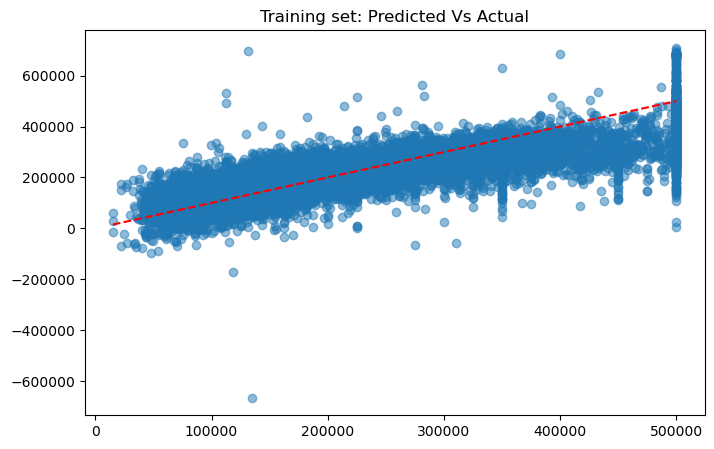

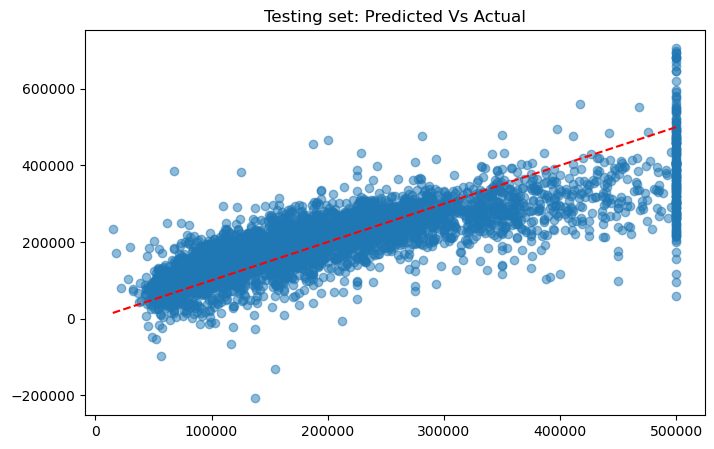

In [103]:
# plotting the training and predicted data
plt.figure(figsize=(8,5))
plt.scatter(y_train,y_pred_train,alpha=0.5)
plt.plot([y_train.min(),y_train.max()],[y_train.min(),y_train.max()],'r--')
plt.title("Training set: Predicted Vs Actual")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred_test,alpha=0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.title("Testing set: Predicted Vs Actual")
plt.show()

In [122]:
# Root mean square error evaluation on train data
rmse_train=np.sqrt(mean_squared_error(y_train,y_pred_train))
rmse_train

np.float64(69362.34135238081)

In [123]:
# Root mean square error evaluation on test data
rmse_test=np.sqrt(mean_squared_error(y_test,y_pred_test))
rmse_test

np.float64(70132.42075871778)

In [124]:
# Percentage Root mean square error evaluation on train data
rmse_train=(rmse_train/y.mean())*100
rmse_train

np.float64(33.53173354700645)

In [125]:
# Percentage of Root mean square error evaluation on test data
rmse_test=(rmse_test/y.mean())*100
rmse_test

np.float64(33.90401188940185)

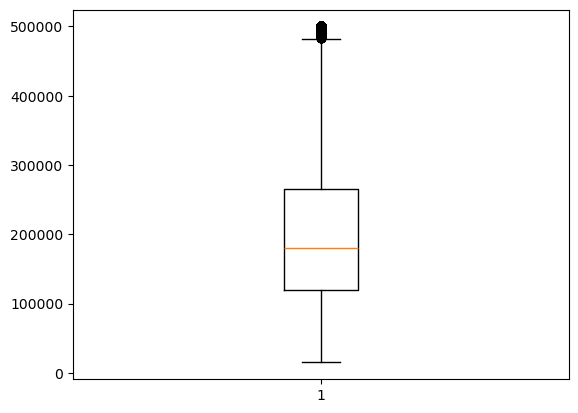

In [131]:
# Box plot to visualize any outliers if there
plt.boxplot(y)
plt.show()

In [133]:
# Identified outliers to fine tune my model
Q1=y.quantile(0.25)
Q3=y.quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=y[(y<lower_bound)|(y>upper_bound)]
print(len(outliers))


1071


In [134]:
 # Log transformation of the target variable to reduce impact of outliers
y_log=np.log(y)

In [137]:
# Re-training my model on log transformed data
X_train,X_test,y_log_train,y_log_test=train_test_split(X,y_log,random_state=42,test_size=0.2)

In [139]:
# calling the model and training the model on training data
lr=LinearRegression()
lr.fit(X_train_scaler,y_log_train)

LinearRegression()

In [141]:
# predicting the house prices on train data
y_log_train_pred=lr.predict(X_train_scaler)
y_log_train_pred

array([12.01397927, 12.45630521, 12.54424469, ..., 12.04281112,
       12.43630455, 12.4263157 ])

In [142]:
# predicting the house price on unseen testing data
y_log_test_pred=lr.predict(X_test_scaler)
y_log_test_pred

array([11.32992906, 12.02032326, 12.66966243, ..., 13.18930335,
       11.64706044, 11.98730504])

In [145]:
# model evaluation using r square for train data
r2_train=r2_score(y_log_train,y_log_train_pred) 
r2_train


0.646364565262832

In [146]:
# evaluation for test data
r2_test=r2_score(y_log_test,y_log_test_pred) 
r2_test

0.6301170046195029

In [148]:
# model evaluation using root mean squared error for test data
rmse_test=np.sqrt(mean_squared_error(y_log_test,y_log_test_pred))
rmse_test

np.float64(0.3464843368933732)

In [149]:
# model evaluation using root mean squared error for train data
rmse_train=np.sqrt(mean_squared_error(y_log_train,y_log_train_pred))
rmse_train

np.float64(0.3383464967930799)

In [150]:
# transforming the logs back to actual salaries
y_pred_salary=np.exp(y_log_test_pred)
y_pred_salary

array([ 83277.11524633, 166096.34024153, 317954.1369593 , ...,
       534615.64603357, 114354.71576603, 160701.68550219])

In [151]:
# computing rmse in real salary
rmse_salary=np.sqrt(mean_squared_error(y_test,y_pred_salary))
rmse_salary

np.float64(93073.50938308173)

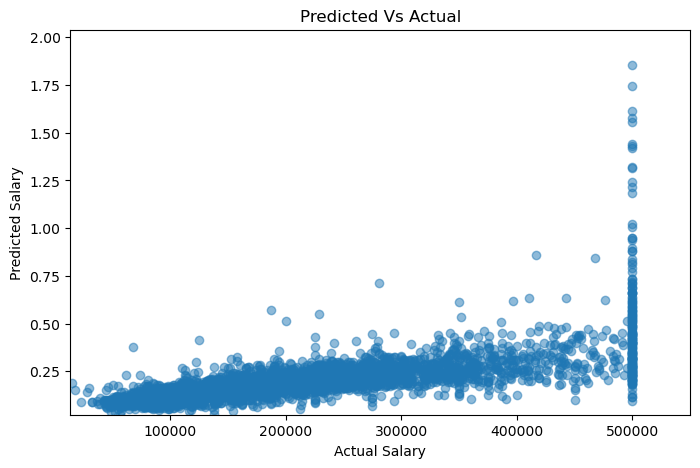

In [169]:
# plotting the predicted salary
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred_salary,alpha=0.5)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted Vs Actual")
plt.xlim(min(y_test)*0.9, max(y_test)*1.1)
plt.ylim(min(y_pred_salary)*0.9, max(y_pred_salary)*1.1)
plt.show()

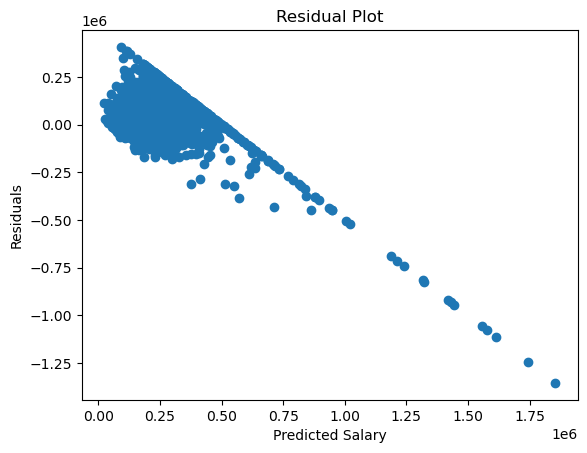

In [155]:
residuals=y_test - y_pred_salary
plt.scatter(y_pred_salary,residuals)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

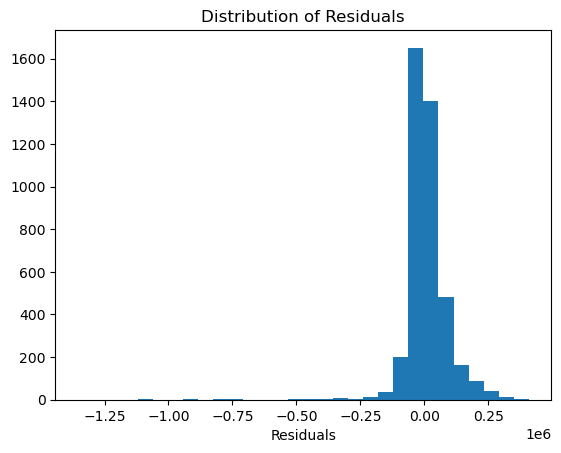

In [156]:
plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()